### 목표 : 프로 선수들의 플레이 스타일과 전투력이 latent space에서 어떻게 구조화되는가?
- 선수 representation 생성
- 플레이 스타일 구조 확인
- PCA component 해석
- robust feature 확인

In [2]:
import pandas as pd 

riot_df = pd.read_csv('RiotAPI데이터_최종백본.csv')

#### Step 1. player-year representation 생성
일단 PCA를 사용할 수 있게 수치형 컬럼들만 골라내고, player-year로 representation 만듦.
그냥 데이터를 바로 사용하면 noise가 너무 크기 때문에 경기들을 평균내서 선수 representation을 생성하자.

In [3]:
# =========================
# PCA용 Riot API 수치형 Feature 선택
# =========================

numeric_features = [

    # 전투
    "kills",
    "deaths",
    "assists",

    "doubleKills",
    "tripleKills",
    "quadraKills",
    "pentaKills",

    # 딜링 / 탱킹
    "totalDamageDealtToChampions",
    "totalDamageTaken",
    "damageSelfMitigated",

    # 군중제어
    "timeCCingOthers",

    # 시야
    "visionScore",
    "wardsPlaced",
    "wardsKilled",
    "visionWardsBoughtInGame",

    # 자원
    "goldEarned",
    "cs",
    "champLevel",

    # 오브젝트
    # "damageDealtToObjectives",
    # "damageDealtToTurrets",

    # "dragonKills",
    # "baronKills",
    # "turretKills",

    # 퍼스트 블러드
    "firstBloodKill",
    "firstBloodAssist",

    # 파생 지표
    "kda",
    "cspm",
    "dpm",

    "earned_gpm",

    "vspm",
    "wpm",
    "wcpm",

    "damagetakenperminute",
    "damagemitigatedperminute"
]


# =========================
# bool -> int 변환
# PCA 전에 숫자로 맞춰줌
# =========================

bool_cols = [
    "win",
    "firstBloodKill",
    "firstBloodAssist"
]

for col in bool_cols:
    riot_df[col] = riot_df[col].astype(int)

# =========================
# Player-Year Representation 생성
# 경기 단위 noise 제거 위해 평균 사용
# =========================

player_vectors = (
    riot_df
    .groupby(
        [
            "playername",
            "game_year",
            "pro_position"
        ]
    )[numeric_features]
    .mean()
    .reset_index()
)

# =========================
# 컬럼명 정리 (선택)
# =========================

player_vectors = player_vectors.rename(
    columns={
        "game_year": "year",
        "pro_position": "position"
    }
)

# =========================
# 확인
# =========================

print(player_vectors.shape)

player_vectors.head(3)


(85, 32)


,playername,year,position,kills,deaths,assists,doubleKills,tripleKills,quadraKills,pentaKills,...,firstBloodAssist,kda,cspm,dpm,earned_gpm,vspm,wpm,wcpm,damagetakenperminute,damagemitigatedperminute
0,Bdd,2024,MIDDLE,7.022059,3.639706,6.529412,0.705882,0.073529,0.0,0.0,...,0.132353,3.893041,8.253982,956.511365,474.664364,0.913066,0.349652,0.155968,725.100839,426.758516
1,Bdd,2025,MIDDLE,7.272727,4.818182,8.454545,0.818182,0.181818,0.0,0.0,...,0.090909,4.574892,7.431432,957.928286,429.433219,0.839336,0.293065,0.128217,843.611257,504.891383
2,BuLLDoG,2026,MIDDLE,5.559767,4.099125,6.717201,0.530612,0.058309,0.0,0.0,...,0.043732,3.232748,8.720702,895.906730,447.527353,1.124013,0.408267,0.168616,822.275188,507.767486


In [4]:
riot_df.columns

Index(['match_id', 'patch', 'game_date', 'game_year', 'game_month', 'puuid',
       'summonerName', 'riotIdGameName', 'championName', 'teamPosition', 'win',
       'gameDuration', 'kills', 'deaths', 'assists', 'doubleKills',
       'tripleKills', 'quadraKills', 'pentaKills',
       'totalDamageDealtToChampions', 'totalDamageTaken',
       'damageSelfMitigated', 'timeCCingOthers', 'visionScore', 'wardsPlaced',
       'wardsKilled', 'visionWardsBoughtInGame', 'goldEarned', 'champLevel',
       'cs', 'damageDealtToObjectives', 'damageDealtToTurrets', 'dragonKills',
       'baronKills', 'turretKills', 'firstBloodKill', 'firstBloodAssist',
       'kda', 'cspm', 'dpm', 'earned_gpm', 'vspm', 'wpm', 'wcpm',
       'damagetakenperminute', 'damagemitigatedperminute', 'playername',
       'pro_position'],
      dtype='object')

#### Step 2. Standardizaion

In [5]:
from sklearn.preprocessing import StandardScaler

X = player_vectors[numeric_features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#### Step 3. PCA 수행

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

#### Step 4. 1차 latent space 시각화(미드랑 정글을 구분해냄)

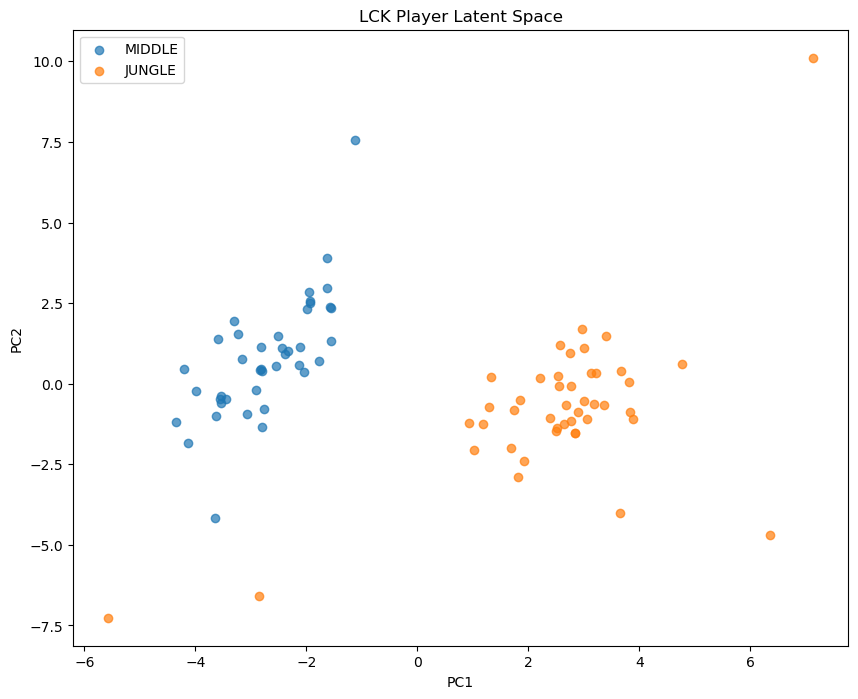

In [7]:
import matplotlib.pyplot as plt

positions = player_vectors["position"].unique()

plt.figure(figsize=(10,8))

for pos in positions:

    idx = (
        player_vectors["position"]
        == pos
    )

    plt.scatter(
        X_pca[idx,0],
        X_pca[idx,1],
        label=pos,
        alpha=0.7
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "LCK Player Latent Space"
)

plt.legend()

plt.show()

#### Step 5. PCA loading
->PCA1, PCA2가 각각 의미하는게 뭔데...

In [8]:
import pandas as pd

# PCA loading dataframe
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=numeric_features
)

# -------------------------
# PC1 양/음 같이 보기
# -------------------------

pc1_sorted = loadings["PC1"].sort_values()

print("===== PC1 음수 방향 =====")
print(pc1_sorted.head(10))

print("\n===== PC1 양수 방향 =====")
print(pc1_sorted.tail(10))

# -------------------------
# PC2 양/음 같이 보기
# -------------------------

pc2_sorted = loadings["PC2"].sort_values()

print("\n===== PC2 음수 방향 =====")
print(pc2_sorted.head(10))

print("\n===== PC2 양수 방향 =====")
print(pc2_sorted.tail(10))

===== PC1 음수 방향 =====
cspm                          -0.247223
cs                            -0.152350
dpm                           -0.109796
quadraKills                   -0.066166
totalDamageDealtToChampions   -0.054200
pentaKills                    -0.052963
wpm                           -0.048962
champLevel                    -0.040195
tripleKills                   -0.025315
wardsPlaced                   -0.007943
Name: PC1, dtype: float64

===== PC1 양수 방향 =====
assists                     0.244267
wcpm                        0.246347
wardsKilled                 0.259445
visionWardsBoughtInGame     0.261165
vspm                        0.275345
visionScore                 0.288033
damagetakenperminute        0.294175
totalDamageTaken            0.295081
damageSelfMitigated         0.309489
damagemitigatedperminute    0.312108
Name: PC1, dtype: float64

===== PC2 음수 방향 =====
damagetakenperminute       -0.071813
firstBloodAssist           -0.044393
visionWardsBoughtInGame    -0.043770

### MID 선수들의 latent playstyle 분석

In [9]:
mid_data = player_vectors[
    player_vectors["position"] == "MIDDLE"
].copy()

#### Step 1. 미드 선수들 뽑아내기

In [10]:
print(mid_data.shape)

print(
    mid_data["playername"].unique()[:10]
)

(41, 32)
['Bdd' 'BuLLDoG' 'Calix' 'Chovy' 'Clozer' 'FATE' 'Faker' 'Fisher' 'Karis'
 'Loki']


#### Step 2. MID feature matrix 생성

In [11]:
X_mid = mid_data[numeric_features]

#### STEP 3. Standardization

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_mid_scaled = scaler.fit_transform(X_mid)

#### STEP 4. MID 전용 PCA

In [13]:
from sklearn.decomposition import PCA

pca_mid = PCA(n_components=2)

X_mid_pca = pca_mid.fit_transform(
    X_mid_scaled
)

#### STEP 5. PCA 좌표 dataframe 생성

In [14]:
mid_data["PC1"] = X_mid_pca[:,0]
mid_data["PC2"] = X_mid_pca[:,1]

#### STEP 6. MID latent space 시각화

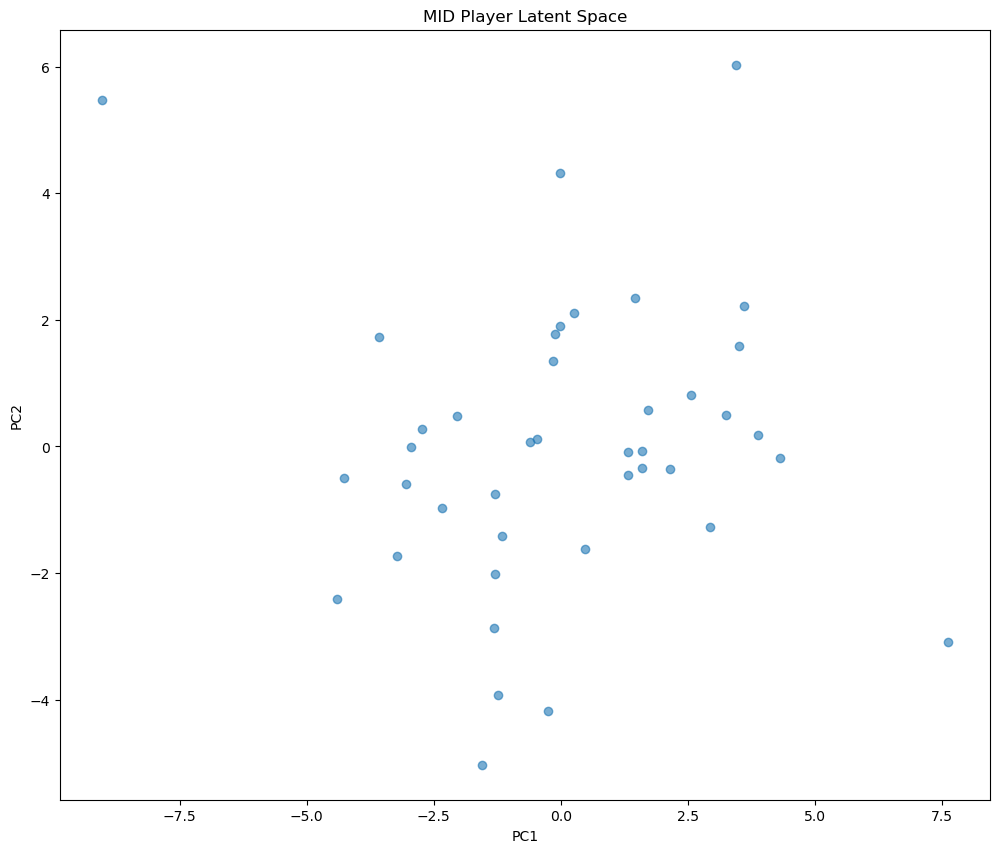

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

plt.scatter(
    mid_data["PC1"],
    mid_data["PC2"],
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "MID Player Latent Space"
)

plt.show()

#### STEP 7. MID PCA loading 분석

In [16]:
# =========================
# PCA Loading DataFrame 생성
# =========================

loading_df = pd.DataFrame(
    pca_mid.components_.T,
    columns=["PC1", "PC2"],
    index=X.columns
)

# =========================
# [1] PC1 먼저 해석
# =========================

pc1_sorted = loading_df.sort_values(
    by="PC1",
    ascending=True
)

print("===================================")
print("PC1 음수 방향 TOP 10")
print("===================================")

print(
    pc1_sorted[["PC1"]].head(10)
)

print("\n")

print("===================================")
print("PC1 양수 방향 TOP 10")
print("===================================")

print(
    pc1_sorted[["PC1"]].tail(10)
)

# --------------------------------------------------
# 여기서 먼저:
# "PC1이 무엇을 의미하는 축인가?"
# 를 해석
# --------------------------------------------------


# =========================
# [2] 그 다음 PC2 해석
# =========================

pc2_sorted = loading_df.sort_values(
    by="PC2",
    ascending=True
)

print("\n\n")

print("===================================")
print("PC2 음수 방향 TOP 10")
print("===================================")

print(
    pc2_sorted[["PC2"]].head(10)
)

print("\n")

print("===================================")
print("PC2 양수 방향 TOP 10")
print("===================================")

print(
    pc2_sorted[["PC2"]].tail(10)
)

# --------------------------------------------------
# 여기서는:
# "PC1으로 설명되지 않는
# 두 번째 플레이 스타일 차이"
# 를 해석
# --------------------------------------------------

PC1 음수 방향 TOP 10
                              PC1
deaths                  -0.162039
tripleKills             -0.066566
quadraKills             -0.046578
firstBloodAssist        -0.038240
pentaKills              -0.004510
damagetakenperminute     0.010826
assists                  0.045147
totalDamageTaken         0.077980
doubleKills              0.101174
visionWardsBoughtInGame  0.130526


PC1 양수 방향 TOP 10
                                  PC1
wardsPlaced                  0.227266
totalDamageDealtToChampions  0.232436
timeCCingOthers              0.235070
earned_gpm                   0.239929
cspm                         0.246751
vspm                         0.251371
champLevel                   0.270401
visionScore                  0.271358
goldEarned                   0.272382
cs                           0.275621



PC2 음수 방향 TOP 10
                       PC2
kda              -0.249978
doubleKills      -0.242997
firstBloodAssist -0.231874
earned_gpm       -0.195155
wcpm             

* 시각화 해보기 

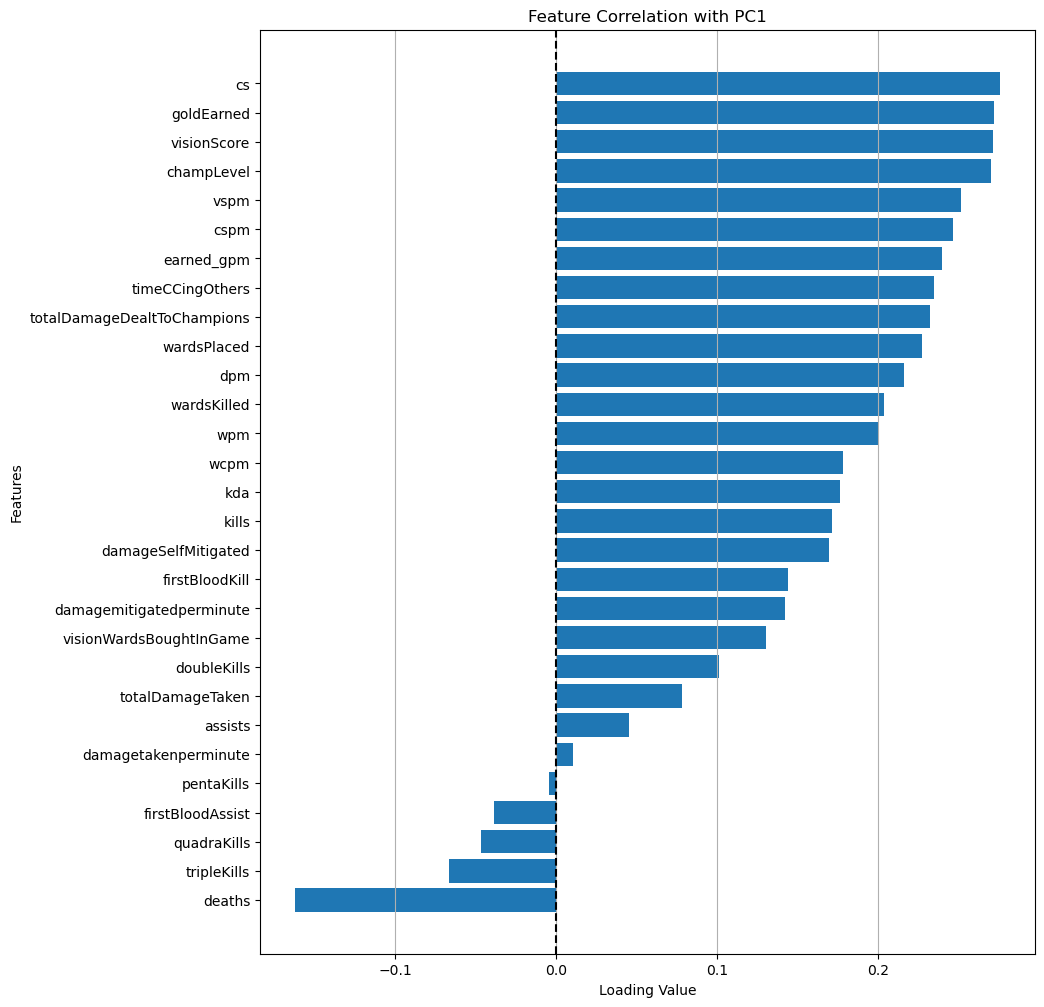

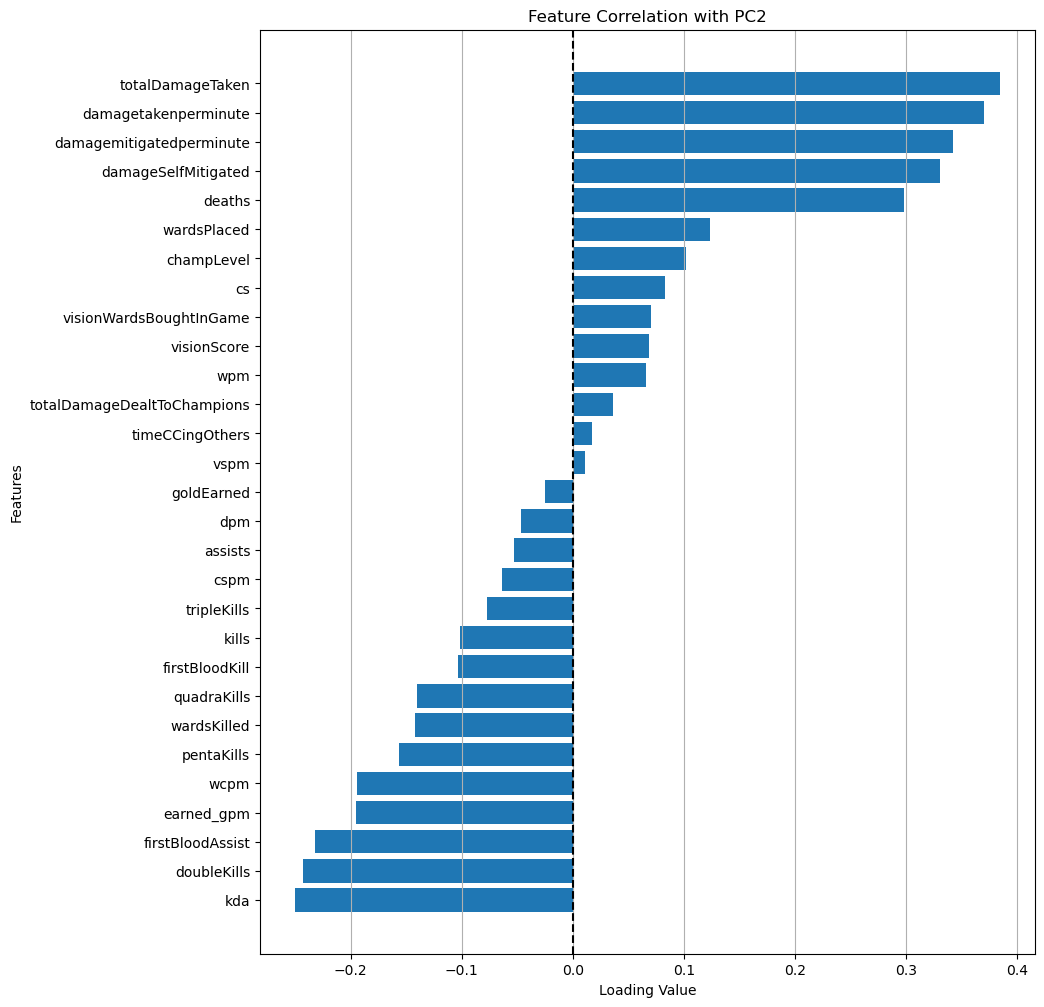

In [24]:
# =========================
# PC1 시각화
# =========================

pc1_sorted = loading_df.sort_values(
    by="PC1"
)

plt.figure(figsize=(10, 12))

plt.barh(
    pc1_sorted.index,
    pc1_sorted["PC1"]
)

plt.axvline(
    x=0,
    color='black',
    linestyle='--'
)

plt.title("Feature Correlation with PC1")
plt.xlabel("Loading Value")
plt.ylabel("Features")

plt.grid(axis='x')

plt.show()


# =========================
# PC2 시각화
# =========================

pc2_sorted = loading_df.sort_values(
    by="PC2"
)

plt.figure(figsize=(10, 12))

plt.barh(
    pc2_sorted.index,
    pc2_sorted["PC2"]
)

plt.axvline(
    x=0,
    color='black',
    linestyle='--'
)

plt.title("Feature Correlation with PC2")
plt.xlabel("Loading Value")
plt.ylabel("Features")

plt.grid(axis='x')

plt.show()


### JGL 선수들의 Latent playstyle 분석

### Step 1. 정글 데이터만 추출

In [17]:
jng_data = player_vectors[
    player_vectors["position"] == "JUNGLE"
].copy()

#### Step 2. PCA 가능하게 Numeric Features만 추출

In [18]:
X_jng = jng_data[numeric_features]

#### Step 3. Standardization

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_jng_scaled = scaler.fit_transform(
    X_jng
)

#### Step 4. PCA 수행

In [20]:
from sklearn.decomposition import PCA

pca_jng = PCA(n_components=2)

X_jng_pca = pca_jng.fit_transform(
    X_jng_scaled
)

#### STEP 5. PCA 좌표 dataframe 생성

In [21]:
jng_data["PC1"] = X_jng_pca[:,0]
jng_data["PC2"] = X_jng_pca[:,1]

#### Step 6. JGL latent space 시각화

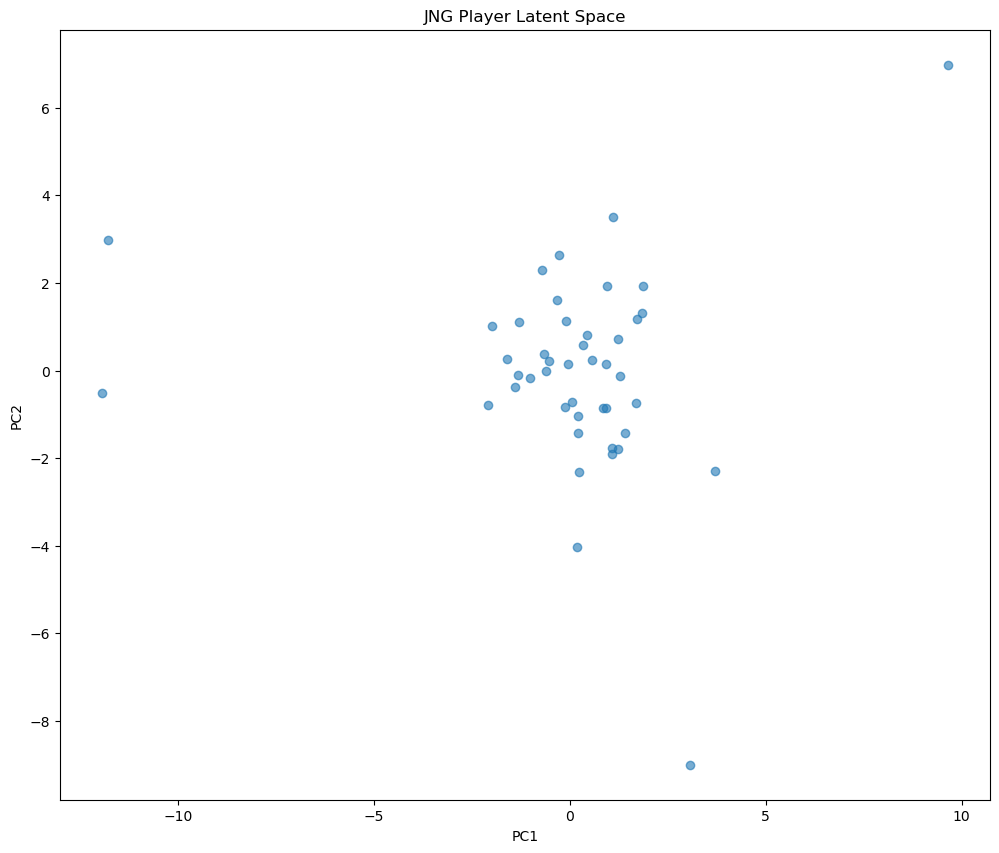

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

plt.scatter(
    jng_data["PC1"],
    jng_data["PC2"],
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    "JNG Player Latent Space"
)

plt.show()

#### Step 7. JGL PCA loading 분석

JUNGLE - PC1 음수 방향 TOP 10
                       PC1
doubleKills      -0.153599
cspm             -0.141778
kda              -0.032916
earned_gpm       -0.028197
wpm              -0.000333
pentaKills        0.008171
firstBloodAssist  0.012124
quadraKills       0.033155
tripleKills       0.075569
vspm              0.124017


JUNGLE - PC1 양수 방향 TOP 10
                                  PC1
deaths                       0.229980
dpm                          0.237845
champLevel                   0.240893
visionScore                  0.242664
goldEarned                   0.253900
damagemitigatedperminute     0.254028
assists                      0.263024
totalDamageDealtToChampions  0.270542
totalDamageTaken             0.271789
damageSelfMitigated          0.280097


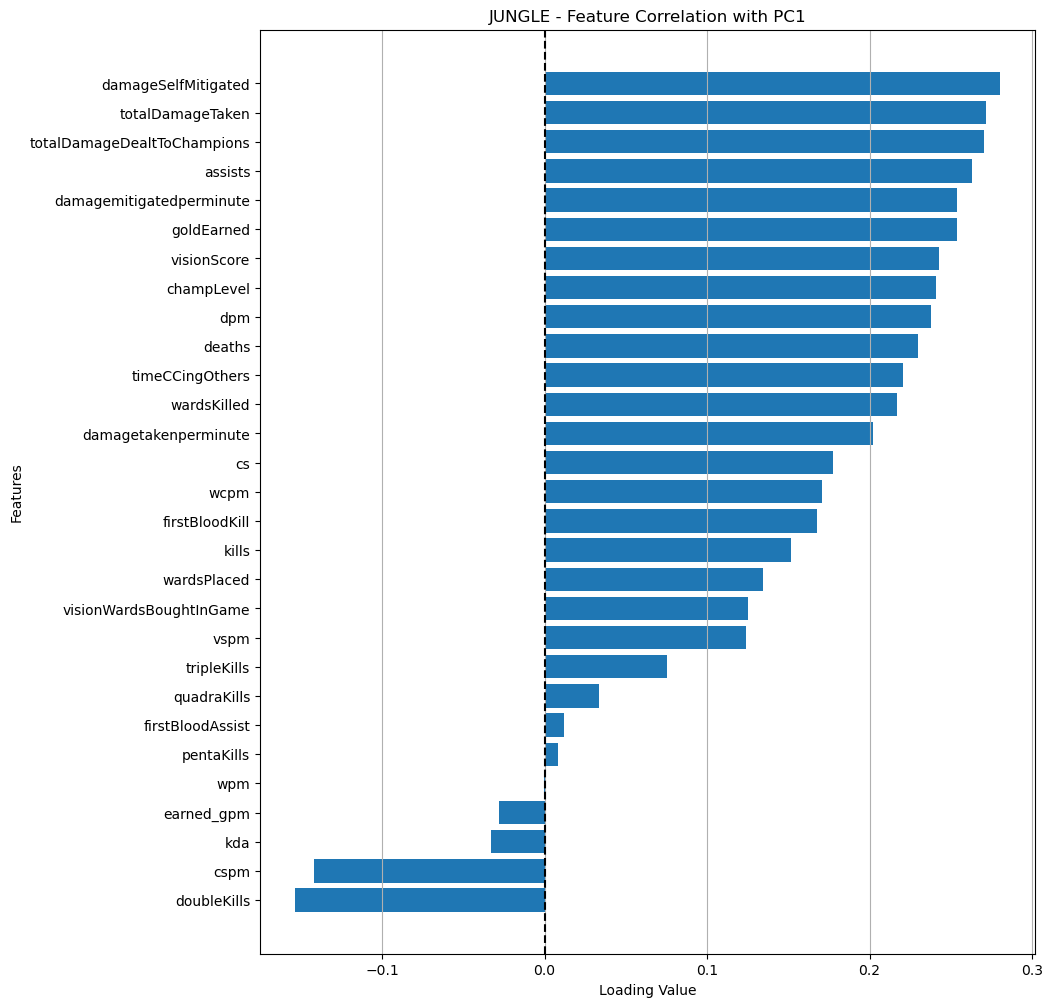




JUNGLE - PC2 음수 방향 TOP 10
                              PC2
wcpm                    -0.194934
deaths                  -0.189465
firstBloodKill          -0.178973
wardsKilled             -0.163135
damagetakenperminute    -0.144872
wpm                     -0.142697
vspm                    -0.142583
visionWardsBoughtInGame -0.141341
wardsPlaced             -0.132285
visionScore             -0.083904


JUNGLE - PC2 양수 방향 TOP 10
                                  PC2
totalDamageDealtToChampions  0.190122
champLevel                   0.201583
dpm                          0.206736
cs                           0.227770
goldEarned                   0.230083
doubleKills                  0.240996
cspm                         0.245330
kda                          0.320217
kills                        0.330938
earned_gpm                   0.358551


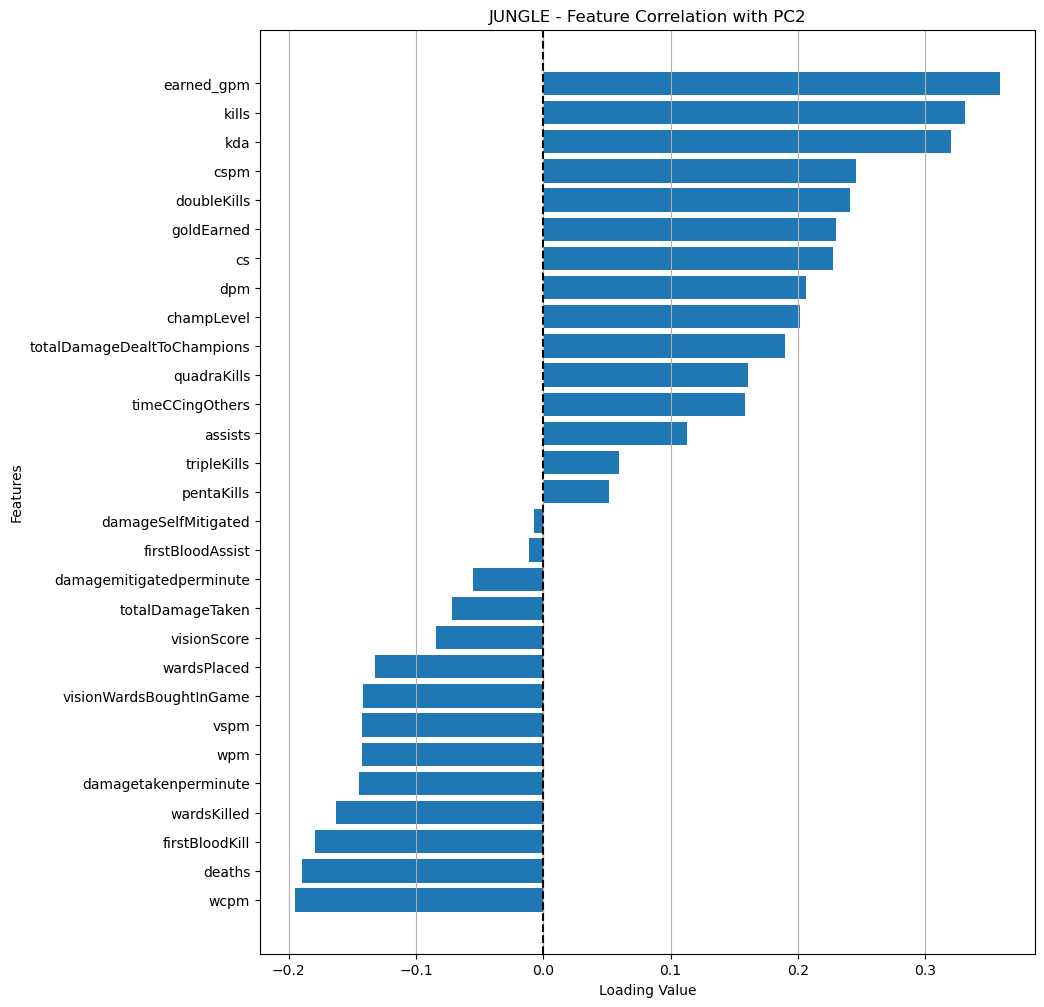

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# JUNGLE PCA Loading DataFrame
# =========================

loading_df = pd.DataFrame(
    pca_jng.components_.T,
    columns=["PC1", "PC2"],
    index=numeric_features
)

# =========================
# [1] PC1 먼저 해석
# =========================

pc1_sorted = loading_df.sort_values(
    by="PC1",
    ascending=True
)

print("===================================")
print("JUNGLE - PC1 음수 방향 TOP 10")
print("===================================")

print(
    pc1_sorted[["PC1"]].head(10)
)

print("\n")

print("===================================")
print("JUNGLE - PC1 양수 방향 TOP 10")
print("===================================")

print(
    pc1_sorted[["PC1"]].tail(10)
)

# =========================
# PC1 시각화
# =========================

plt.figure(figsize=(10, 12))

plt.barh(
    pc1_sorted.index,
    pc1_sorted["PC1"]
)

plt.axvline(
    x=0,
    color='black',
    linestyle='--'
)

plt.title("JUNGLE - Feature Correlation with PC1")
plt.xlabel("Loading Value")
plt.ylabel("Features")

plt.grid(axis='x')

plt.show()


# ==================================================
# 여기서 먼저:
# "정글에서 가장 큰 분산은 무엇인가?"
# 를 해석
# ==================================================



# =========================
# [2] 그 다음 PC2 해석
# =========================

pc2_sorted = loading_df.sort_values(
    by="PC2",
    ascending=True
)

print("\n\n")

print("===================================")
print("JUNGLE - PC2 음수 방향 TOP 10")
print("===================================")

print(
    pc2_sorted[["PC2"]].head(10)
)

print("\n")

print("===================================")
print("JUNGLE - PC2 양수 방향 TOP 10")
print("===================================")

print(
    pc2_sorted[["PC2"]].tail(10)
)

# =========================
# PC2 시각화
# =========================

plt.figure(figsize=(10, 12))

plt.barh(
    pc2_sorted.index,
    pc2_sorted["PC2"]
)

plt.axvline(
    x=0,
    color='black',
    linestyle='--'
)

plt.title("JUNGLE - Feature Correlation with PC2")
plt.xlabel("Loading Value")
plt.ylabel("Features")

plt.grid(axis='x')

plt.show()


# ==================================================
# 여기서는:
# "정글 내부 플레이 스타일 차이"
# 를 해석
# ==================================================